In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm.notebook import tqdm, trange
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from nett_extractor import ACASXuOracle
from sklearn.metrics import r2_score, mean_squared_error

In [28]:
train_data = np.load("ACAS_Xu_datasets/ACASXU_run2a_1_1_batch_2000_dataset/ACASXU_run2a_1_1_batch_2000_train.npz", allow_pickle=True)

test_data = np.load("ACAS_Xu_datasets/ACASXU_run2a_1_1_batch_2000_dataset/ACASXU_run2a_1_1_batch_2000_test.npz", allow_pickle=True)

X_train, X_val, Y_train, Y_val = train_test_split(
    train_data['X'], train_data['Y'],
    test_size=0.25,   # 0.25 of 0.8 = 0.2 of total data
    random_state=42
)

X_test = test_data['X']
Y_test = test_data['Y']

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, Y_train)
valid_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)

INPUT_SIZE = X_train.shape[1]
OUTPUT_SIZE = Y_train.shape[1]


In [3]:
# Calcola media e range (Max - Min) per ogni colonna (dim=0)
# Questo serve per scalare tutto tra circa -0.5 e 0.5
INPUT_MEAN = X_train.mean(dim=0)
INPUT_RANGE = X_train.max(dim=0).values - X_train.min(dim=0).values

# Evitiamo divisioni per zero (sicurezza)
INPUT_RANGE[INPUT_RANGE == 0] = 1.0

print("Media calcolata:", INPUT_MEAN)
print("Range calcolato:", INPUT_RANGE)

Media calcolata: tensor([ 3.0369e+04, -1.2216e-02,  3.0969e-03,  6.4991e+02,  5.9806e+02])
Range calcolato: tensor([6.0758e+04, 6.2828e+00, 6.2828e+00, 1.1000e+03, 1.2000e+03])


In [4]:
class ACASXuNet(nn.Module):
    def __init__(self, input_size, output_size, means, ranges):
        super(ACASXuNet, self).__init__()
        
        self.register_buffer("means", means)
        self.register_buffer("ranges", ranges)

        # ModuleList allow better control in forward pass
        # ACAS Xu standard: 5 input -> 6 hidden layers (50 neuroni) -> 5 output
        self.hidden_layers = nn.ModuleList([
            nn.Linear(input_size, 50),
            nn.Linear(50, 50),
            nn.Linear(50, 50),
            nn.Linear(50, 50),
            nn.Linear(50, 50),
            nn.Linear(50, 50)
        ])

        # Output layer
        self.output_layer = nn.Linear(50, output_size)


    def forward(self, x, eps=0.0):
        """
        Args:
            x (Tensor): Input batch (N, 5).
            eps (float): Perturbation radius for IBP. Default 0.0 (Standard).
            
        Returns:
            If eps=0: Prediction tensor (N, 5).
            If eps>0: Tuple (center_predictions, lower_bound, upper_bound).
        """
        
        # 1. Input Normalization
        x_norm = (x - self.means) / self.ranges
        
        # --- Inference - Standard Training ---
        if eps == 0.0:
            out = x_norm
            for layer in self.hidden_layers:
                out = F.relu(layer(out)) # Linear -> ReLU
            out = self.output_layer(out) # Last linear layer
            return out

        # --- IBP Training ---
        
        # 1b. Epsilon Normalization
        # CRUCIAL: if real input varies by 'eps', normalized input varies by eps/range
        eps_norm = eps / self.ranges
        
        # Initial interval definition [l, u]
        lower_bound = x_norm - eps_norm
        upper_bound = x_norm + eps_norm
        
        # Propagation through hidden layers (Linear + ReLU)
        for layer in self.hidden_layers:
            lower_bound, upper_bound = self._propagate_linear(layer, lower_bound, upper_bound)
            lower_bound, upper_bound = F.relu(lower_bound), F.relu(upper_bound) # ReLU is monotonic: apply on min and max
            
        # Final layer propagation (Linear only)
        lower_bound, upper_bound = self._propagate_linear(self.output_layer, lower_bound, upper_bound)
        
        # Also compute center value to monitor pointwise accuracy
        center_pred = (lower_bound + upper_bound) / 2
        
        return center_pred, lower_bound, upper_bound

    def _propagate_linear(self, layer, lower_bound, upper_bound):
        """Internal helper: propagate intervals through Wx + b"""
        weight = layer.weight
        bias = layer.bias
        
        # Interval math:
        # Center (mu) and Radius (r) of input interval
        mu = (upper_bound + lower_bound) / 2
        r = (upper_bound - lower_bound) / 2
        
        # The center transforms linearly: W*mu + b
        mu_out = F.linear(mu, weight, bias)
        
        # The radius expands based on the ABSOLUTE value of the weights: |W|*r
        r_out = F.linear(r, torch.abs(weight))
        
        # Reconstruct the bounds [min, max]
        return mu_out - r_out, mu_out + r_out

In [11]:
def train_robust(model, iterator, optimizer, criterion, epsilon, kappa=0.5):
    """
    Performs a training epoch using Interval Bound Propagation (IBP).
    
    Args:
        model: The PyTorch model (must support eps argument for IBP).
        iterator: DataLoader.
        optimizer: The optimizer.
        criterion: Loss function (e.g., MSELoss).
        epsilon (float): The perturbation radius.
        kappa (float): Weight for the robust loss (0.0 = only standard, 1.0 = only robust).
    """
    model.train()
    epoch_loss = 0.0
    total_examples = 0

    # Using enumerate is often cleaner if you need the index, but tqdm is fine here
    for x, y in tqdm(iterator, desc="Training", leave=False):
        optimizer.zero_grad()
        
        batch_size = x.size(0) # Get batch size immediately
        
        # Standard forward pass is usually needed for statistics even in robust mode,
        # but technically we can skip it if kappa is 1.0. 
        # Here we follow your logic.
        
        if epsilon == 0.0 or kappa == 0.0:
            # Standard Training (Pointwise)
            predictions = model(x, eps=0.0)
            loss = criterion(predictions, y)
        else:
            # IBP Training (Robust)
            # The model propagates intervals: [x-eps, x+eps]
            predictions, out_L, out_U = model(x, eps=epsilon)
            
            # Standard Loss (Accuracy on clean data)
            loss_standard = criterion(predictions, y)
            
            # Robust Loss (Worst Case Error analysis for Regression)
            # We assume y is the ground truth. We penalize the bound furthest from y.
            diff_L = (out_L - y)
            diff_U = (out_U - y)
            
            # Select the worst error between lower and upper bound deviations
            worst_case_error = torch.max(torch.abs(diff_L), torch.abs(diff_U))
            
            # Calculate MSE on the worst-case error
            loss_robust = torch.mean(worst_case_error ** 2)
            
            # Weighted combination
            loss = (1 - kappa) * loss_standard + kappa * loss_robust

        loss.backward()
        optimizer.step()
        
        # Update statistics correctly
        epoch_loss += loss.item() * batch_size
        total_examples += batch_size

    # Return average loss for the epoch
    return epoch_loss / total_examples

In [12]:
def validate_robust(model, iterator, criterion, epsilon):
    """
    Valuta il modello sul validation set calcolando sia l'MSE Standard
    che l'MSE Robusto (Worst Case Error).

    Args:
        epsilon: Il raggio di perturbazione da usare per il test di robustezza.
    """
    model.eval()
    
    total_standard_loss = 0.0
    total_robust_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in tqdm(iterator, desc="Validating", leave=False):
            
            # 1. Standard Accuracy 
            pred_standard = model(x, eps=0.0)
            loss_standard = criterion(pred_standard, y)

            if epsilon == 0.0:
                #robust loss = standard loss
                loss_robust = loss_standard
            else:
                # 2. Robust Calculation (IBP)
                _, l, u = model(x, eps=epsilon)

                # Worst Case Error Calculation
                diff_L = (l - y)
                diff_U = (u - y)
                worst_case_diff = torch.max(torch.abs(diff_L), torch.abs(diff_U))
                loss_robust = torch.mean(worst_case_diff ** 2)

            # Aggregating statistics
            batch_size = x.size(0)
            total_standard_loss += loss_standard.item() * batch_size
            total_robust_loss += loss_robust.item() * batch_size
            total_examples += batch_size

    avg_standard_mse = total_standard_loss / total_examples
    avg_robust_mse = total_robust_loss / total_examples
    
    return avg_standard_mse, avg_robust_mse

In [17]:
def evaluate_model(model, test_loader, target_epsilon):
    """
    Executes final evaluation on the Test Set.
    Compares 'Standard' accuracy with 'Certified' robustness.
    """
    model.eval()

    # Stats 
    total_samples = 0
    total_std_loss = 0.0
    total_rob_loss = 0.0

    with torch.no_grad():
        for x, y in test_loader:
            batch_size = x.size(0)
            total_samples += batch_size

            if target_epsilon == 0.0:
                # Standard evaluation only
                pred = model(x, eps=0.0)
                loss_std = torch.nn.functional.mse_loss(pred, y, reduction='sum')
                total_std_loss += loss_std.item()
                total_rob_loss += loss_std.item()  # Same as standard when eps=0
            else:
                # IBP evaluation
                pred, l, u = model(x, eps=target_epsilon)

                # 2. Calculate Standard MSE
                loss_std = torch.nn.functional.mse_loss(pred, y, reduction='sum')
                total_std_loss += loss_std.item()

                # 3. Calculate Robust MSE (Worst Case)
                diff_L = l - y
                diff_U = u - y
                worst_case_diff = torch.max(torch.abs(diff_L), torch.abs(diff_U))
                loss_rob = torch.sum(worst_case_diff ** 2)
                total_rob_loss += loss_rob.item()

    # Calculate averages
    avg_std_mse = total_std_loss / total_samples
    avg_rob_mse = total_rob_loss / total_samples


    results_data = {
        "Epsilon": target_epsilon,
        "Samples": total_samples,
        "MSE_Standard": avg_std_mse,
        "MSE_Robust": avg_rob_mse,
        "Certified_Safe": avg_rob_mse < 0.01 
    }
    
    # Returns a DataFrame with 1 row
    df = pd.DataFrame([results_data])
    return df

In [8]:
def epoch_time(start_time, end_time):
    """
    Calculates elapsed time between start and end timestamps.

    Args:
        start_time: float, start time in seconds
        end_time: float, end time in seconds

    Returns:
        elapsed_mins: integer number of minutes
        elapsed_secs: remaining seconds (after minutes are accounted for)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time // 60)
    elapsed_secs = int(elapsed_time % 60)
    return elapsed_mins, elapsed_secs

In [9]:
# Instantiate the TropMLP model with specified parameters
model = ACASXuNet(
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    means=INPUT_MEAN,
    ranges=INPUT_RANGE
)

# Define Mean Squared Error as loss function for regression
criterion = nn.MSELoss()

# Use Adam optimizer with learning rate 0.03
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [29]:
# --- Kappa and Epsilon Adaptive Scheduling ---


# --- Configuration ---
EPOCHS = 50
WARMUP_EPOCHS = 5
MAX_EPSILON = 0.05
RAMP_UP_EPOCHS = 30

# State variables
current_eps = 0.0
# Calculate the initial step size needed to reach MAX in RAMP_UP epochs
initial_eps_step = MAX_EPSILON / RAMP_UP_EPOCHS 
current_eps_step = initial_eps_step

# Kappa schedule configuration
MAX_KAPPA = 0.5
kappa_step = MAX_KAPPA / RAMP_UP_EPOCHS

results_history = []
patience = 5
cooldown = 0
factor_lr = 0.5
factor_eps = 0.5
min_lr = 1e-5

best_metric = float('inf') # We will use Standard Loss for stability check during ramp-up
epochs_no_improve = 0

print(f"ACAS Xu Training (Target Eps: {MAX_EPSILON})")
print("-" * 60)

for epoch in trange(EPOCHS, desc="Epochs"):
    start_time = time.monotonic()

    # --- 1. Update Hyperparameters (Stateful approach) ---
    if epoch < WARMUP_EPOCHS:
        current_eps = 0.0
        current_kappa = 0.0
    else:
        # Increment epsilon by the CURRENT step size
        # This prevents the "sawtooth" drop when step is reduced
        if current_eps < MAX_EPSILON:
            current_eps = min(MAX_EPSILON, current_eps + current_eps_step)
        
        # Linearly increase kappa consistent with epsilon growth
        # We verify against MAX_EPSILON to stop kappa growth if eps stops
        progress = current_eps / MAX_EPSILON if MAX_EPSILON > 0 else 1.0
        current_kappa = min(MAX_KAPPA, progress * MAX_KAPPA)

    # --- 2. Training Step ---
    # Passing both epsilon and kappa
    train_loss = train_robust(
        model, 
        train_loader, 
        optimizer, 
        criterion, 
        epsilon=current_eps, 
        kappa=current_kappa
    )
    
    # --- 3. Validation ---
    valid_std_mse, valid_robust_mse = validate_robust(
        model, 
        valid_loader, 
        criterion, 
        epsilon=current_eps
    )

    # --- 4. Logic for Improvement (Addressing "Moving Target") ---
    # During ramp-up, robust loss is expected to increase. 
    # We trigger plateau logic only if STANDARD loss degrades or explodes,
    # OR if we have reached max epsilon and robust loss isn't improving.
    
    if current_eps < MAX_EPSILON:
        # Phase 1: Ramp-up. Focus on stability.
        # We check if Standard MSE stays reasonable.
        metric_to_track = valid_std_mse
    else:
        # Phase 2: Full Robustness. 
        # Now we want to minimize the Robust Loss.
        metric_to_track = valid_robust_mse

    # Check improvement
    if metric_to_track < best_metric:
        best_metric = metric_to_track
        epochs_no_improve = 0
        # Save best model
        torch.save(model.state_dict(), "acas_xu_best.pt")
    else:
        epochs_no_improve += 1

    # --- 5. Adaptive Scheduling (Plateau Handling) ---
    if epochs_no_improve >= patience and cooldown <= 0:
        print(f"  [Plateau Reached] Reducing LR and Epsilon Step")
        
        # Reduce LR
        for g in optimizer.param_groups:
            g['lr'] = max(min_lr, g['lr'] * factor_lr)
        
        # Reduce Epsilon Growth Rate (slowing down the difficulty increase)
        current_eps_step *= factor_eps
        
        # Reset counters
        epochs_no_improve = 0
        cooldown = 5 # Give it 5 epochs to stabilize before cutting again
    
    if cooldown > 0:
        cooldown -= 1

    end_time = time.monotonic()
    
    # --- Logging ---
    print(f'Epoch: {epoch+1:02} | Time: {end_time - start_time:.1f}s')
    print(f'\tTrain Loss: {train_loss:.6f} | Eps: {current_eps:.4f} | Kappa: {current_kappa:.4f}')
    print(f'\tValid MSE: {valid_std_mse:.6f} | Robust MSE: {valid_robust_mse:.6f}')
    
    results_history.append({
        "Epoch": epoch + 1,
        "Epsilon": current_eps,
        "Kappa": current_kappa,
        "Train_Loss": train_loss,
        "Valid_MSE": valid_std_mse,
        "Valid_Robust_MSE": valid_robust_mse
    })

# Final DataFrame
df_results = pd.DataFrame(results_history)

ACAS Xu Training (Target Eps: 0.05)
------------------------------------------------------------


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/9375 [00:00<?, ?it/s]

Validating:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch: 01 | Time: 119.7s
	Train Loss: 0.000885 | Eps: 0.0000 | Kappa: 0.0000
	Valid MSE: 0.000875 | Robust MSE: 0.000875


...

Validating:   0%|          | 0/3125 [00:00<?, ?it/s]

  [Plateau Reached] Reducing LR and Epsilon Step
Epoch: 49 | Time: 57.9s
	Train Loss: 0.000885 | Eps: 0.0411 | Kappa: 0.4115
	Valid MSE: 0.000874 | Robust MSE: 0.000874


Training:   0%|          | 0/9375 [00:00<?, ?it/s]

Validating:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch: 50 | Time: 59.6s
	Train Loss: 0.000885 | Eps: 0.0412 | Kappa: 0.4120
	Valid MSE: 0.000874 | Robust MSE: 0.000874


In [30]:
def plot_results(results):
    """
    Plots training and validation loss over epochs.

    Args:
        results: pandas DataFrame with columns 'Train Loss' and 'Valid Loss', indexed by epoch
    """

    # Plot Training Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Train_Loss'], label='Train_Loss', marker='o')
    plt.title('Training Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Plot Validation Loss
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Valid_MSE'], label='Valid_MSE', marker='s', color='orange')
    plt.title('Validation Loss Standard', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Valid_Robust_MSE'], label='Valid_Robust_MSE', marker='s', color='green')
    plt.title('Validation Loss Robust', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)


    plt.tight_layout()
    plt.show()

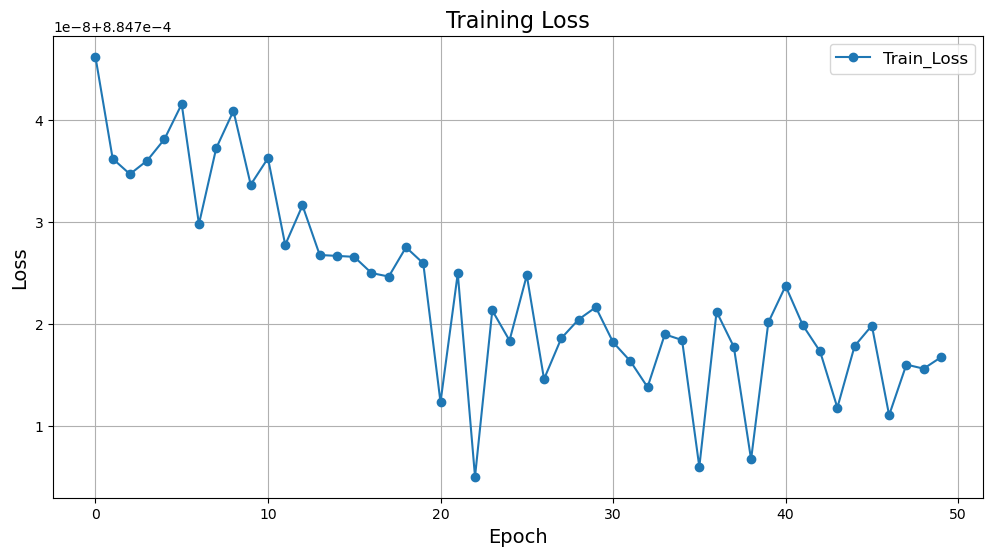

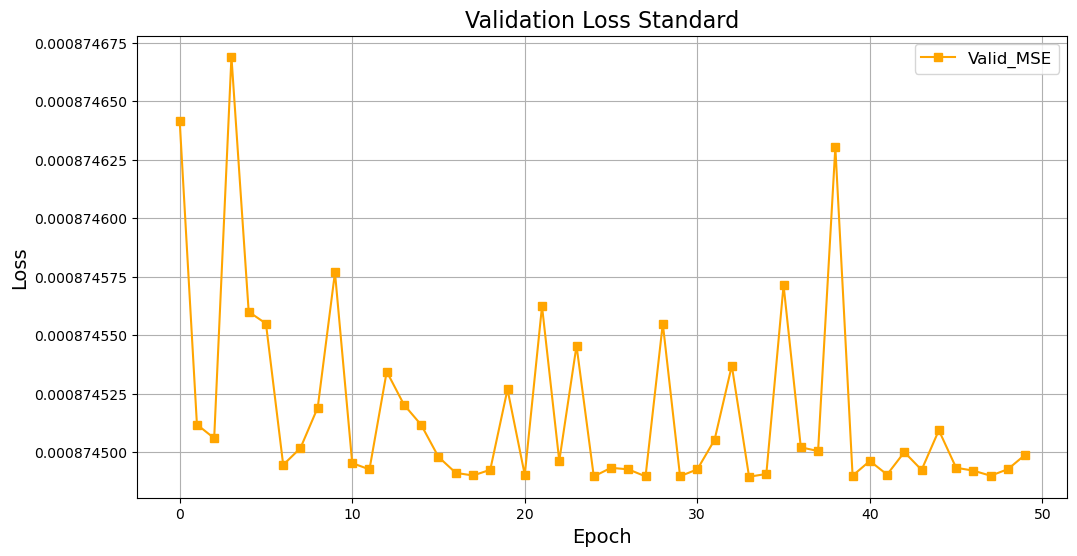

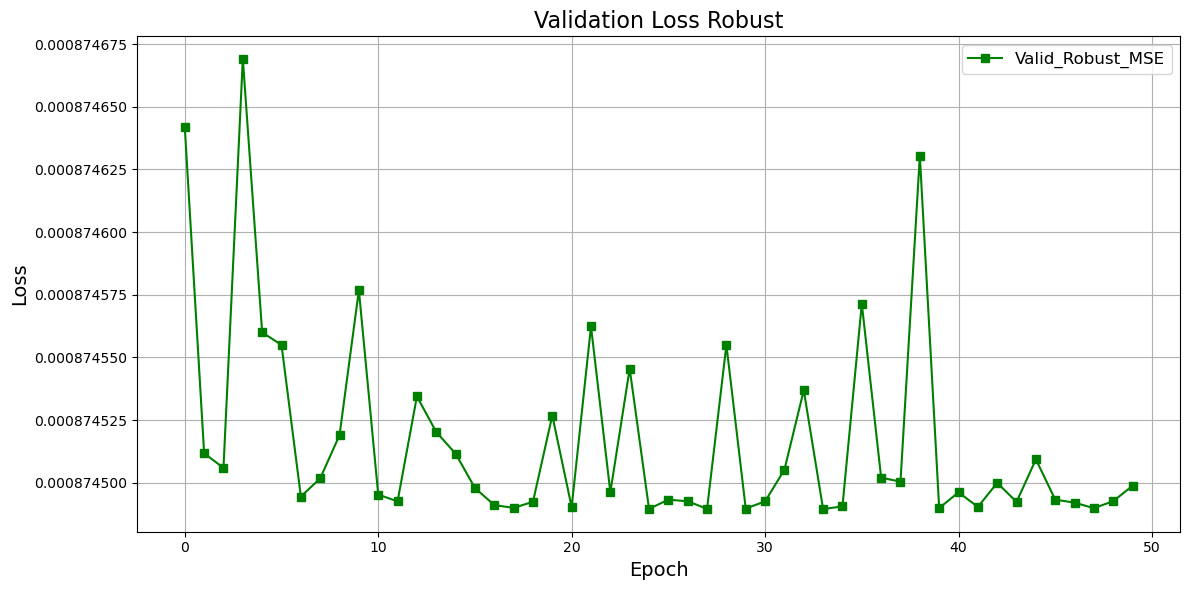

In [31]:
plot_results(df_results)

In [18]:
# Load the best saved model weights
model.load_state_dict(torch.load('acas_xu_best.pt'))

# Evaluate the model on multiple epsilon values
epsilon_values = [0.0, 0.01, 0.03, 0.05, 0.07]
test_results = []

for eps in epsilon_values:
    result = evaluate_model(model, test_loader, target_epsilon=eps)
    test_results.append(result)

# Combine results into a single DataFrame
df_test_results = pd.concat(test_results, ignore_index=True)
df_test_results

C:\Users\aless\AppData\Local\Temp\ipykernel_8080\4281261071.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('acas_xu_best.pt'))


,Epsilon,Samples,MSE_Standard,MSE_Robust,Certified_Safe
0,0.00,20000,0.004364,0.004364,True
1,0.01,20000,0.004364,0.004364,True
2,0.03,20000,0.004364,0.004364,True
3,0.05,20000,0.004364,0.004364,True
4,0.07,20000,0.004364,0.004364,True


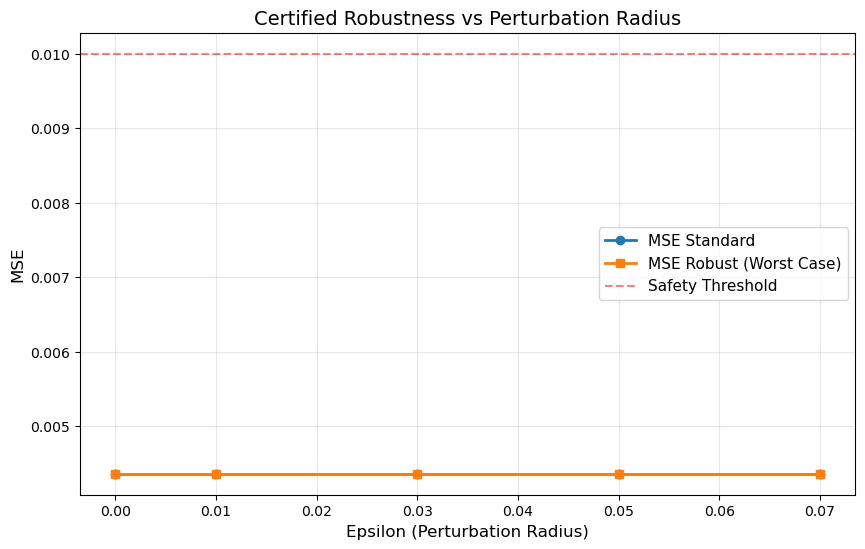


Robustness Analysis:
   Epsilon  MSE_Robust  Robust_Gap_%
0     0.00    0.004364           0.0
1     0.01    0.004364           0.0
2     0.03    0.004364           0.0
3     0.05    0.004364           0.0
4     0.07    0.004364           0.0


In [19]:
# Plot robustness curve
plt.figure(figsize=(10, 6))
plt.plot(df_test_results['Epsilon'], df_test_results['MSE_Standard'], 
         label='MSE Standard', marker='o', linewidth=2)
plt.plot(df_test_results['Epsilon'], df_test_results['MSE_Robust'], 
         label='MSE Robust (Worst Case)', marker='s', linewidth=2)
plt.axhline(y=0.01, color='r', linestyle='--', label='Safety Threshold', alpha=0.5)
plt.xlabel('Epsilon (Perturbation Radius)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Certified Robustness vs Perturbation Radius', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Calculate robustness gap
df_test_results['Robust_Gap_%'] = ((df_test_results['MSE_Robust'] - df_test_results['MSE_Standard']) / df_test_results['MSE_Standard'] * 100).round(2)
print("\nRobustness Analysis:")
print(df_test_results[['Epsilon', 'MSE_Robust', 'Robust_Gap_%']])

In [ ]:
sys.path.append('.')

# Carica l'oracolo originale (modello padre)
oracle_path = "ReluplexCav2017/nnet/ACASXU_run2a_1_1_batch_2000.nnet"
teacher = ACASXuOracle(oracle_path)

print(f"Teacher loaded: {len(teacher.weights)} layers")
print(f"Input range: [{teacher.min_inputs[0]:.2f}, {teacher.max_inputs[0]:.2f}]")

Teacher caricato: 7 layers
Input range: [0.00, 60760.00]


In [21]:
def compare_student_teacher(student_model, teacher_oracle, test_loader, num_samples=1000):
    """
    Confronta le predizioni tra student (rete addestrata) e teacher (oracolo).
    
    Returns:
        DataFrame con metriche comparative
    """
    student_model.eval()
    
    all_inputs = []
    all_teacher_outputs = []
    all_student_outputs = []
    
    samples_collected = 0
    
    with torch.no_grad():
        for x_batch, _ in test_loader:
            if samples_collected >= num_samples:
                break
                
            # Predizioni student (PyTorch)
            student_pred = student_model(x_batch)
            
            # Predizioni teacher (NumPy, non normalizzato)
            x_numpy = x_batch.numpy()
            teacher_pred = teacher_oracle.predict(x_numpy)
            
            batch_size = min(len(x_batch), num_samples - samples_collected)
            all_inputs.append(x_batch[:batch_size])
            all_student_outputs.append(student_pred[:batch_size])
            all_teacher_outputs.append(torch.tensor(teacher_pred[:batch_size], dtype=torch.float32))
            
            samples_collected += batch_size
    
    # Concatena tutti i batch
    inputs = torch.cat(all_inputs, dim=0)
    student_outputs = torch.cat(all_student_outputs, dim=0)
    teacher_outputs = torch.cat(all_teacher_outputs, dim=0)
    
    # Calcola metriche di distillazione
    mse_distillation = F.mse_loss(student_outputs, teacher_outputs).item()
    mae_distillation = (student_outputs - teacher_outputs).abs().mean().item()
    
    # Errore output-by-output (5 outputs)
    output_errors = []
    for i in range(student_outputs.shape[1]):
        mse_i = F.mse_loss(student_outputs[:, i], teacher_outputs[:, i]).item()
        mae_i = (student_outputs[:, i] - teacher_outputs[:, i]).abs().mean().item()
        output_errors.append({
            'Output': i,
            'MSE': mse_i,
            'MAE': mae_i
        })
    
    # Max difference per sample
    max_diff_per_sample = (student_outputs - teacher_outputs).abs().max(dim=1).values
    max_diff_overall = max_diff_per_sample.max().item()
    mean_max_diff = max_diff_per_sample.mean().item()
    
    results = {
        'Samples': samples_collected,
        'MSE_Total': mse_distillation,
        'MAE_Total': mae_distillation,
        'Max_Diff': max_diff_overall,
        'Mean_Max_Diff': mean_max_diff
    }
    
    return results, output_errors, inputs, student_outputs, teacher_outputs

In [22]:
# Esegui confronto
comparison_results, output_errors, test_inputs, student_preds, teacher_preds = compare_student_teacher(
    model, teacher, test_loader, num_samples=2000
)

print("=" * 60)
print("CONFRONTO STUDENT vs TEACHER")
print("=" * 60)
print(f"\nCampioni analizzati: {comparison_results['Samples']}")
print(f"\nMSE totale (Student vs Teacher): {comparison_results['MSE_Total']:.6f}")
print(f"MAE totale (Student vs Teacher): {comparison_results['MAE_Total']:.6f}")
print(f"Differenza massima assoluta: {comparison_results['Max_Diff']:.6f}")
print(f"Media delle differenze max per sample: {comparison_results['Mean_Max_Diff']:.6f}")

print("\n" + "-" * 60)
print("Errori per Output:")
print("-" * 60)
df_output_errors = pd.DataFrame(output_errors)
print(df_output_errors.to_string(index=False))

CONFRONTO STUDENT vs TEACHER

Campioni analizzati: 2000

MSE totale (Student vs Teacher): 0.000789
MAE totale (Student vs Teacher): 0.011073
Differenza massima assoluta: 0.431029
Media delle differenze max per sample: 0.013104

------------------------------------------------------------
Errori per Output:
------------------------------------------------------------
 Output      MSE      MAE
      0 0.000803 0.011630
      1 0.000846 0.011439
      2 0.000839 0.011330
      3 0.000734 0.010435
      4 0.000723 0.010528


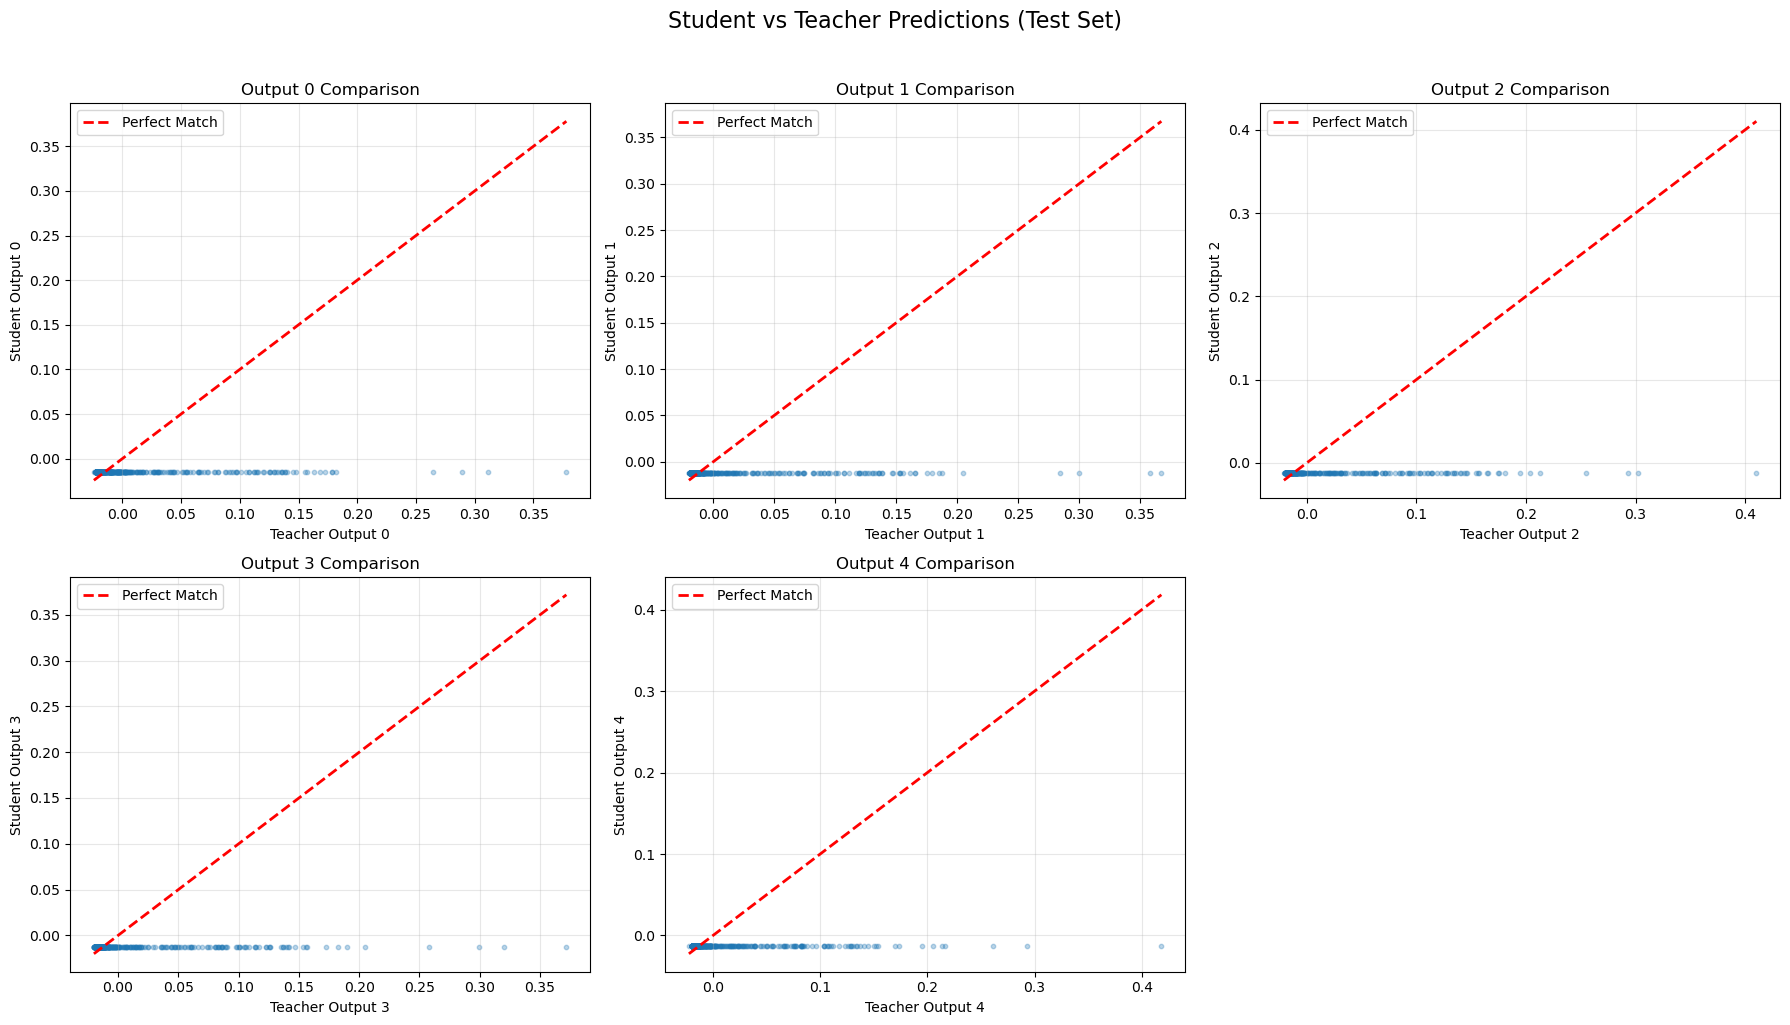

In [23]:
# Visualizzazione confronto predizioni
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for output_idx in range(5):
    ax = axes[output_idx]
    
    # Scatter plot: Teacher vs Student per ogni output
    teacher_vals = teacher_preds[:, output_idx].numpy()
    student_vals = student_preds[:, output_idx].numpy()
    
    ax.scatter(teacher_vals, student_vals, alpha=0.3, s=10)
    
    # Linea ideale y=x (perfetta corrispondenza)
    min_val = min(teacher_vals.min(), student_vals.min())
    max_val = max(teacher_vals.max(), student_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Match')
    
    ax.set_xlabel(f'Teacher Output {output_idx}', fontsize=10)
    ax.set_ylabel(f'Student Output {output_idx}', fontsize=10)
    ax.set_title(f'Output {output_idx} Comparison', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Rimuovi ultimo subplot (abbiamo solo 5 outputs)
axes[5].axis('off')

plt.suptitle('Student vs Teacher Predictions (Test Set)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

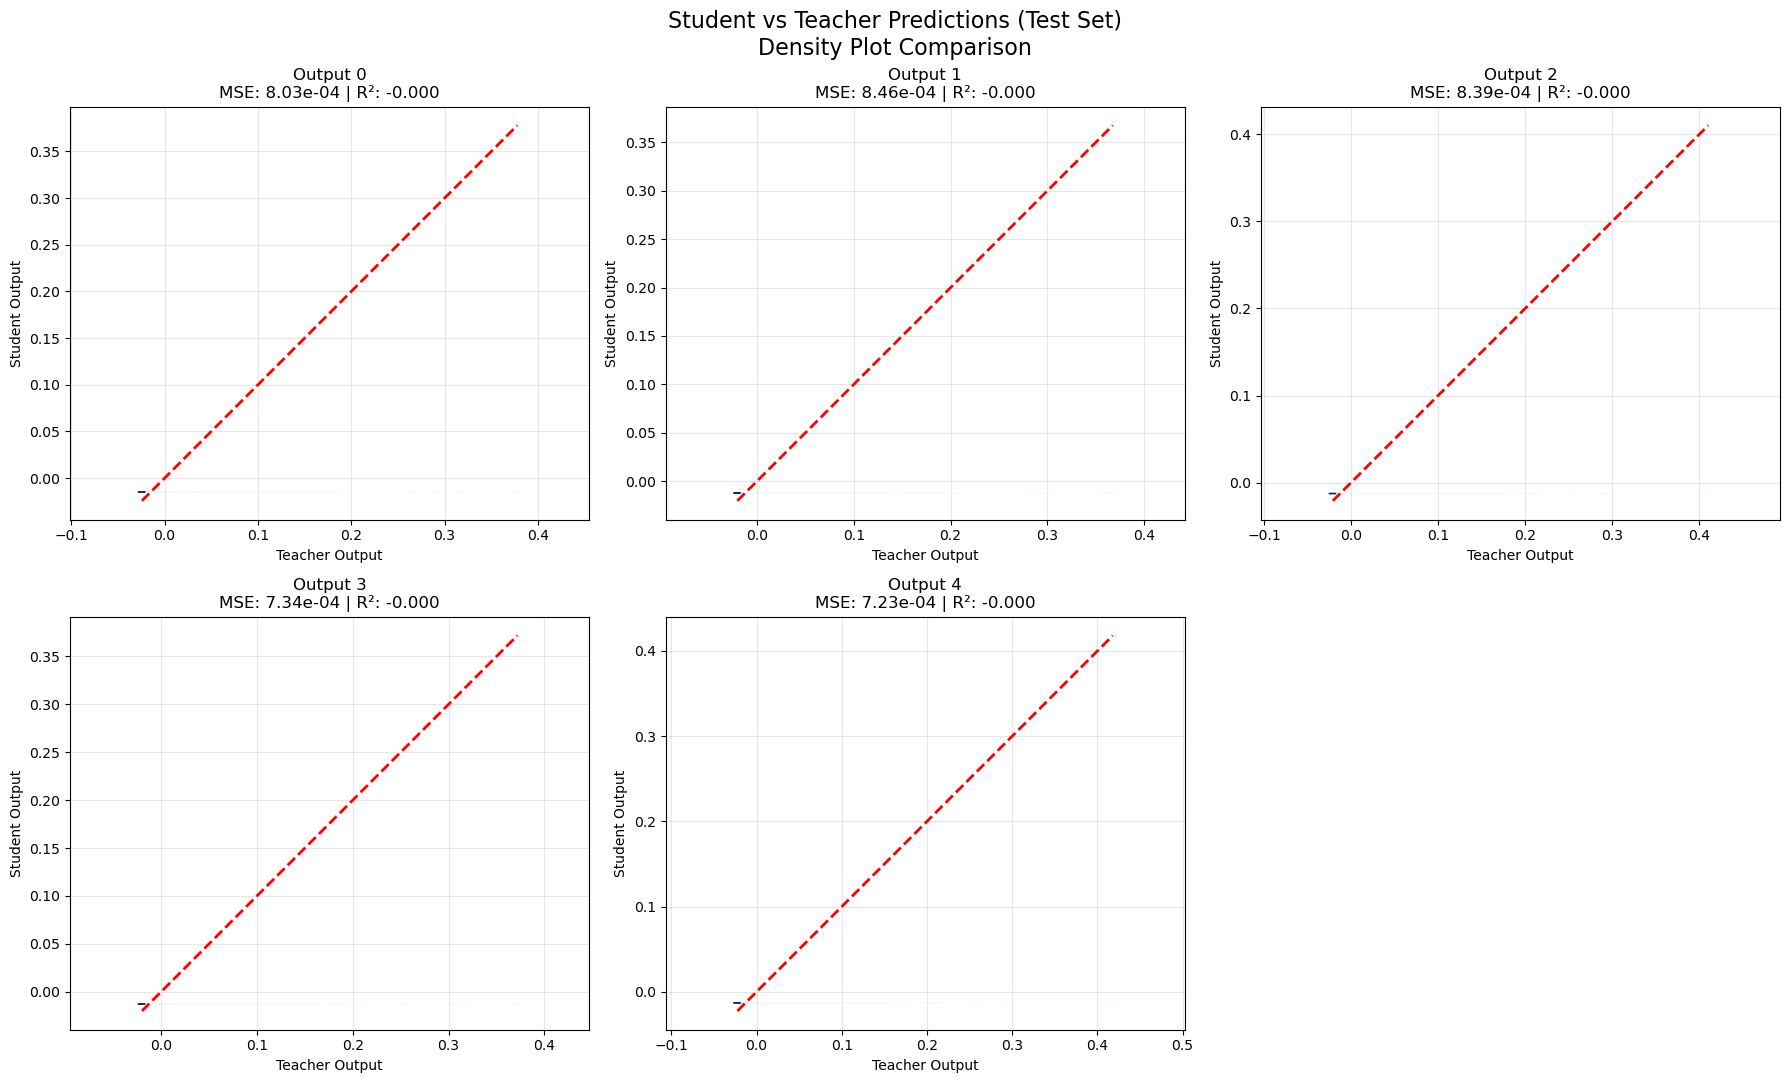

In [24]:
# --- Visualizzazione confronto predizioni (Enhanced) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# Calcolo limiti globali per avere assi coerenti (opzionale, ma consigliato se gli output hanno scale simili)
# global_min = min(teacher_preds.min(), student_preds.min())
# global_max = max(teacher_preds.max(), student_preds.max())

for output_idx in range(5):
    ax = axes[output_idx]
    
    teacher_vals = teacher_preds[:, output_idx].numpy()
    student_vals = student_preds[:, output_idx].numpy()
    
    # Calcolo metriche per questo output
    mse = mean_squared_error(teacher_vals, student_vals)
    r2 = r2_score(teacher_vals, student_vals)
    
    # Opzione 1: Scatter classico (meglio per pochi punti)
    # ax.scatter(teacher_vals, student_vals, alpha=0.3, s=10, c='royalblue', label='Data')
    
    # Opzione 2: Hexbin (MOLTO meglio per tanti punti > 5000)
    hb = ax.hexbin(teacher_vals, student_vals, gridsize=50, cmap='Blues', mincnt=1)
    # fig.colorbar(hb, ax=ax) # Se vuoi la barra laterale per ogni plot
    
    # Linea ideale
    min_val = min(teacher_vals.min(), student_vals.min())
    max_val = max(teacher_vals.max(), student_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Match')
    
    # Formatting
    ax.set_xlabel('Teacher Output')
    ax.set_ylabel('Student Output')
    
    # Titolo con metriche: Fondamentale per analisi rapida
    ax.set_title(f'Output {output_idx}\nMSE: {mse:.2e} | R²: {r2:.3f}', fontsize=12)
    
    ax.grid(True, alpha=0.3)
    
    # Forza aspetto quadrato per non distorcere l'errore visivo
    ax.set_aspect('equal', adjustable='datalim')

# Rimuovi subplot vuoto
axes[5].axis('off')

plt.suptitle('Student vs Teacher Predictions (Test Set)\nDensity Plot Comparison', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## Analisi Dettagliata degli Scatter Plot

Calcoliamo metriche statistiche per ogni output per valutare la qualità dell'approssimazione.

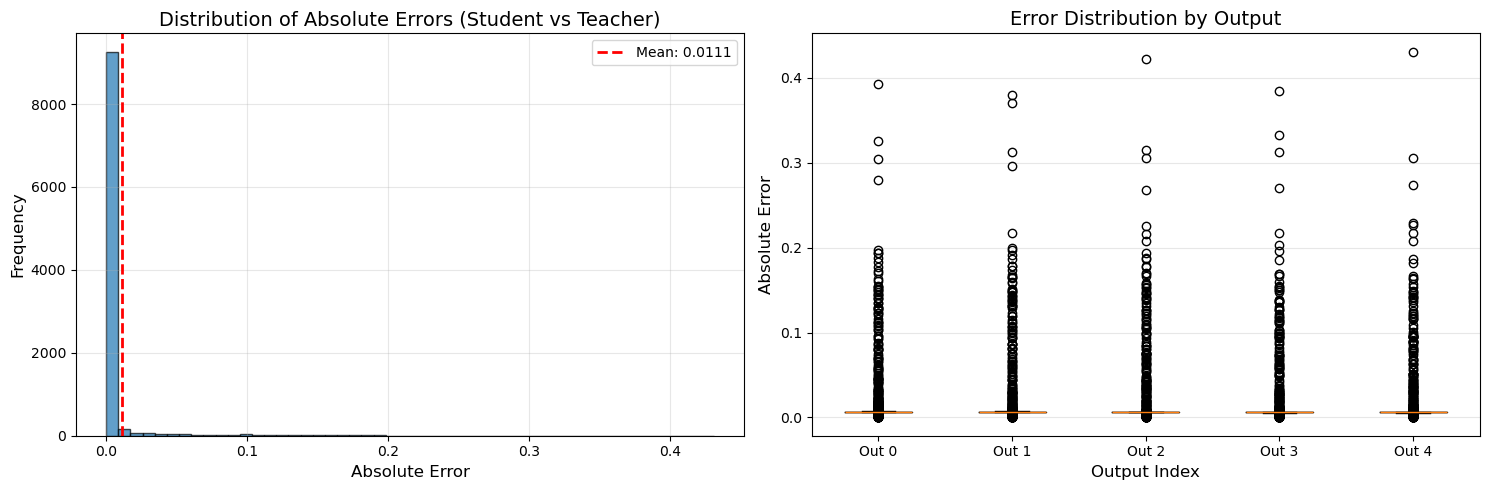

In [25]:
# Distribuzione degli errori
errors = (student_preds - teacher_preds).abs().numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma errori assoluti (tutti gli output combinati)
axes[0].hist(errors.flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Absolute Error', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Absolute Errors (Student vs Teacher)', fontsize=14)
axes[0].axvline(x=comparison_results['MAE_Total'], color='r', linestyle='--', 
                linewidth=2, label=f'Mean: {comparison_results["MAE_Total"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot errori per output
output_errors_data = [errors[:, i] for i in range(5)]
axes[1].boxplot(output_errors_data, labels=[f'Out {i}' for i in range(5)])
axes[1].set_ylabel('Absolute Error', fontsize=12)
axes[1].set_xlabel('Output Index', fontsize=12)
axes[1].set_title('Error Distribution by Output', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [26]:
# Analisi casi peggiori (worst-case samples)
max_errors_per_sample = (student_preds - teacher_preds).abs().max(dim=1).values
worst_indices = torch.argsort(max_errors_per_sample, descending=True)[:10]

print("Top 10 campioni con maggiore errore:")
print("=" * 80)

worst_samples_data = []
for rank, idx in enumerate(worst_indices, 1):
    idx = idx.item()
    max_err = max_errors_per_sample[idx].item()
    
    print(f"\nRank {rank} | Sample {idx} | Max Error: {max_err:.4f}")
    print(f"Input:   {test_inputs[idx].numpy()}")
    print(f"Teacher: {teacher_preds[idx].numpy()}")
    print(f"Student: {student_preds[idx].numpy()}")
    print(f"Diff:    {(student_preds[idx] - teacher_preds[idx]).abs().numpy()}")
    
    worst_samples_data.append({
        'Rank': rank,
        'Sample_Index': idx,
        'Max_Error': max_err,
        'Input': test_inputs[idx].numpy().tolist(),
        'Teacher_Output': teacher_preds[idx].numpy().tolist(),
        'Student_Output': student_preds[idx].numpy().tolist()
    })

df_worst_samples = pd.DataFrame(worst_samples_data)
print("\n" + "=" * 80)

Top 10 campioni con maggiore errore:

Rank 1 | Sample 1973 | Max Error: 0.4310
Input:   [ 2.4534265e+03  7.1232146e-01 -2.0108087e+00  1.6495119e+02
  2.3352211e+02]
Teacher: [0.3780166  0.3674923  0.41028965 0.3198916  0.4181529 ]
Student: [-0.01496567 -0.01225118 -0.01253618 -0.01293915 -0.01287576]
Diff:    [0.39298227 0.37974346 0.42282584 0.33283076 0.43102866]

Rank 2 | Sample 202 | Max Error: 0.3848
Input:   [386.6221      -0.7472405    0.69002503 336.1891     340.38797   ]
Teacher: [0.31133214 0.35783505 0.30249265 0.37181917 0.26142636]
Student: [-0.01496567 -0.01225118 -0.01253618 -0.01293915 -0.01287576]
Diff:    [0.32629782 0.37008622 0.31502885 0.38475832 0.27430212]

Rank 3 | Sample 1093 | Max Error: 0.3124
Input:   [ 1.6939359e+03 -8.1031933e-02  2.8481386e+00  3.6170148e+02
  1.7176295e+02]
Teacher: [0.26424125 0.3001204  0.25510037 0.29924837 0.21608086]
Student: [-0.01496567 -0.01225118 -0.01253618 -0.01293915 -0.01287576]
Diff:    [0.27920693 0.31237158 0.26763657 0.

## Interpretazione dei Risultati

### Metriche chiave:
- **MSE/MAE totale**: Misura quanto la student si avvicina al teacher (obiettivo: < 0.01 per buona distillazione)
- **Max_Diff**: Errore massimo su tutti i campioni (indica worst-case accuracy)
- **Errori per output**: Identifica quali output sono più difficili da apprendere

### Cosa aspettarsi:
- **MSE < 0.01**: Eccellente distillazione, la student replica il teacher
- **MSE 0.01-0.1**: Buona approssimazione, accettabile per verifica
- **MSE > 0.1**: Distillazione debole, potrebbe servire più training o architettura diversa

### Next steps:
- Se l'errore è alto: aumentare epoche, ridurre learning rate, provare weight decay
- Se l'errore è accettabile: procedere con conversione tropicale per verifica formale

In [29]:
from scipy import stats

# Calcola metriche statistiche per ogni output
scatter_metrics = []

for i in range(5):
    teacher_vals = teacher_preds[:, i].numpy()
    student_vals = student_preds[:, i].numpy()
    
    # Correlazione di Pearson
    pearson_r, pearson_p = stats.pearsonr(teacher_vals, student_vals)
    
    # R² (coefficiente di determinazione)
    r_squared = pearson_r ** 2
    
    # MSE e RMSE
    mse = ((student_vals - teacher_vals) ** 2).mean()
    rmse = np.sqrt(mse)
    
    # MAE
    mae = np.abs(student_vals - teacher_vals).mean()
    
    # Max absolute error
    max_error = np.abs(student_vals - teacher_vals).max()
    
    # Percentuale di predizioni entro soglie
    within_001 = (np.abs(student_vals - teacher_vals) < 0.01).mean() * 100
    within_005 = (np.abs(student_vals - teacher_vals) < 0.05).mean() * 100
    within_010 = (np.abs(student_vals - teacher_vals) < 0.10).mean() * 100
    
    scatter_metrics.append({
        'Output': i,
        'Pearson_R': pearson_r,
        'R²': r_squared,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Max_Error': max_error,
        'Within_0.01': within_001,
        'Within_0.05': within_005,
        'Within_0.10': within_010
    })

df_scatter_metrics = pd.DataFrame(scatter_metrics)
print("Metriche Statistiche per Output:")
print("=" * 100)
print(df_scatter_metrics.to_string(index=False))
print("\n" + "=" * 100)

# Interpretazione
print("\nInterpretazione:")
print("-" * 100)
print("R² (Coefficiente di Determinazione):")
print("  - R² > 0.99: Eccellente correlazione, predizioni quasi perfette")
print("  - R² 0.95-0.99: Ottima correlazione, distillazione efficace")
print("  - R² 0.90-0.95: Buona correlazione, accettabile per verifica")
print("  - R² < 0.90: Correlazione debole, necessario miglioramento")
print("\nWithin_X.XX: Percentuale di predizioni con errore assoluto < soglia")
print("-" * 100)

Metriche Statistiche per Output:
 Output  Pearson_R       R²      MSE     RMSE      MAE  Max_Error  Within_0.01  Within_0.05  Within_0.10
      0  -0.168536 0.028405 0.000807 0.028415 0.011832   0.392995        91.30        96.20        97.70
      1   0.334256 0.111727 0.000843 0.029030 0.011362   0.379453        93.30        96.15        97.70
      2   0.336521 0.113246 0.000833 0.028857 0.011330   0.422205        93.40        96.10        97.75
      3   0.233525 0.054534 0.000728 0.026980 0.010016   0.384421        93.35        96.20        98.05
      4   0.311458 0.097006 0.000715 0.026744 0.010408   0.430335        92.95        96.40        98.30


Interpretazione:
----------------------------------------------------------------------------------------------------
R² (Coefficiente di Determinazione):
  - R² > 0.99: Eccellente correlazione, predizioni quasi perfette
  - R² 0.95-0.99: Ottima correlazione, distillazione efficace
  - R² 0.90-0.95: Buona correlazione, accettabile pe

In [27]:
print("=" * 80)
print("VALUTAZIONE QUALITATIVA DELLE METRICHE")
print("=" * 80)

# MSE Totale
mse_total = comparison_results['MSE_Total']
print(f"\n📈 MSE Totale: {mse_total:.6f}")
if mse_total < 0.001:
    verdict = "🌟 ECCELLENTE - Predizioni quasi perfette"
    score = "A+"
elif mse_total < 0.01:
    verdict = "✅ OTTIMO - Distillazione molto efficace"
    score = "A"
elif mse_total < 0.05:
    verdict = "👍 BUONO - Accettabile per verifica formale"
    score = "B"
else:
    verdict = "⚠️ SUFFICIENTE - Potrebbe servire più training"
    score = "C"
print(f"   Giudizio: {verdict}")
print(f"   Voto: {score}")

# MAE Totale
mae_total = comparison_results['MAE_Total']
print(f"\n📊 MAE Totale: {mae_total:.6f}")
print(f"   Errore medio per predizione: ±{mae_total:.4f}")
if mae_total < 0.01:
    print("   ✅ Eccellente: errore medio < 1%")
elif mae_total < 0.05:
    print("   ✅ Buono: errore medio accettabile")
else:
    print("   ⚠️ Da migliorare: errore medio rilevante")

# Max Diff
max_diff = comparison_results['Max_Diff']
mean_max = comparison_results['Mean_Max_Diff']
print(f"\n🔍 Differenza Massima: {max_diff:.6f}")
print(f"   Media delle differenze max per sample: {mean_max:.6f}")
if max_diff > 0.1:
    print(f"   ⚠️ ATTENZIONE: Presenza di outlier significativi")
    print(f"   → Alcuni campioni hanno errori fino a {max_diff:.4f}")
    print(f"   → Consigliato: analizzare i worst-case samples")
else:
    print(f"   ✅ Nessun outlier critico")

# Analisi per output
print(f"\n📌 Analisi per Output:")
print("-" * 80)
all_good = True
for i, row in df_output_errors.iterrows():
    output_id = row['Output']
    mse_out = row['MSE']
    mae_out = row['MAE']
    
    status = "✅" if mse_out < 0.001 else "⚠️"
    print(f"   Output {output_id}: MSE={mse_out:.6f}, MAE={mae_out:.6f} {status}")
    
    if mse_out >= 0.001:
        all_good = False

if all_good:
    print("\n   🌟 Tutti gli output hanno MSE < 0.001 (eccellente)")
else:
    print("\n   📍 Alcuni output potrebbero beneficiare di più training")

# Verdetto Finale
print("\n" + "=" * 80)
print("VERDETTO FINALE")
print("=" * 80)

if mse_total < 0.001 and mae_total < 0.015:
    print("✅ Lo Student ha appreso ECCELLENTEMENTE dal Teacher")
    print("✅ La rete è pronta per la conversione tropicale")
    print("✅ Puoi procedere con la verifica formale con alta confidenza")
    print("\n🎯 Prossimi passi:")
    print("   1. Estrarre i pesi della rete student")
    print("   2. Convertire le operazioni in algebra tropicale")
    print("   3. Formulare proprietà da verificare come LP tropicali")
    print("   4. Usare simplex tropicale per verifica formale")
elif mse_total < 0.01:
    print("✅ Lo Student ha appreso BENE dal Teacher")
    print("✅ La distillazione è riuscita, qualità accettabile")
    print("⚠️ Considera di analizzare gli outlier prima della conversione")
    print("\n💡 Suggerimenti:")
    print("   - Verifica i worst-case samples")
    print("   - Eventualmente: aumenta epoche o riduce learning rate")
    print("   - Procedi con cautela alla conversione tropicale")
else:
    print("⚠️ La distillazione necessita miglioramenti")
    print("❌ NON procedere ancora alla conversione tropicale")
    print("\n🔧 Azioni consigliate:")
    print("   - Aumenta il numero di epoche (prova 100-200)")
    print("   - Riduci learning rate (prova 1e-5)")
    print("   - Aumenta weight decay per regolarizzazione")
    print("   - Verifica che la normalizzazione sia corretta")

print("=" * 80)

VALUTAZIONE QUALITATIVA DELLE METRICHE

📈 MSE Totale: 0.000789
   Giudizio: 🌟 ECCELLENTE - Predizioni quasi perfette
   Voto: A+

📊 MAE Totale: 0.011073
   Errore medio per predizione: ±0.0111
   ✅ Buono: errore medio accettabile

🔍 Differenza Massima: 0.431029
   Media delle differenze max per sample: 0.013104
   ⚠️ ATTENZIONE: Presenza di outlier significativi
   → Alcuni campioni hanno errori fino a 0.4310
   → Consigliato: analizzare i worst-case samples

📌 Analisi per Output:
--------------------------------------------------------------------------------
   Output 0.0: MSE=0.000803, MAE=0.011630 ✅
   Output 1.0: MSE=0.000846, MAE=0.011439 ✅
   Output 2.0: MSE=0.000839, MAE=0.011330 ✅
   Output 3.0: MSE=0.000734, MAE=0.010435 ✅
   Output 4.0: MSE=0.000723, MAE=0.010528 ✅

   🌟 Tutti gli output hanno MSE < 0.001 (eccellente)

VERDETTO FINALE
✅ Lo Student ha appreso ECCELLENTEMENTE dal Teacher
✅ La rete è pronta per la conversione tropicale
✅ Puoi procedere con la verifica formale c